# Migration Analysis

### Import Libraries

In [38]:
# Import libraries
import networkx as nx
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import asyn_lpa_communities
import pandas as pd
import matplotlib.pyplot as plt
import math
from collections import Counter

### Create Network Graph

In [39]:
# State abbreviation dictionary
state_abbrev = {
    "Alabama": "AL","Alaska": "AK","Arizona": "AZ","Arkansas": "AR",
    "California": "CA","Colorado": "CO","Connecticut": "CT","Delaware": "DE",
    "Florida": "FL","Georgia": "GA","Hawaii": "HI","Idaho": "ID",
    "Illinois": "IL","Indiana": "IN","Iowa": "IA","Kansas": "KS",
    "Kentucky": "KY","Louisiana": "LA","Maine": "ME","Maryland": "MD",
    "Massachusetts": "MA","Michigan": "MI","Minnesota": "MN","Mississippi": "MS",
    "Missouri": "MO","Montana": "MT","Nebraska": "NE","Nevada": "NV",
    "New Hampshire": "NH","New Jersey": "NJ","New Mexico": "NM","New York": "NY",
    "North Carolina": "NC","North Dakota": "ND","Ohio": "OH","Oklahoma": "OK",
    "Oregon": "OR","Pennsylvania": "PA","Rhode Island": "RI","South Carolina": "SC",
    "South Dakota": "SD","Tennessee": "TN","Texas": "TX","Utah": "UT",
    "Vermont": "VT","Virginia": "VA","Washington": "WA","West Virginia": "WV",
    "Wisconsin": "WI","Wyoming": "WY"
}

# Convert csv as dataframe
df = pd.read_csv("data/migration_network.csv")

# Keep necessary columns
df = df[["o_cz_name","o_state_name","d_cz_name","d_state_name","n"]].dropna(subset=["o_cz_name","o_state_name","d_cz_name","d_state_name","n"])

# Convert n to numeric and drop non-numeric
df["n"] = pd.to_numeric(df["n"], errors="coerce")
df = df.dropna(subset=["n"])

# Remove zero-weight edges
df = df[df["n"] > 0]

# Convert state names to abbreviations
df["o_state_abbr"] = df["o_state_name"].map(state_abbrev)
df["d_state_abbr"] = df["d_state_name"].map(state_abbrev)
df = df.dropna(subset=["o_state_abbr","d_state_abbr"])

# Create "City, ST" format
df["Origin"] = df["o_cz_name"].astype(str).str.strip() + ", " + df["o_state_abbr"]
df["Dest"]   = df["d_cz_name"].astype(str).str.strip() + ", " + df["d_state_abbr"]

# Remove self-loops
df = df[df["Origin"] != df["Dest"]]

# Create empty multi-directed graph (parallel edges allowed)
Gw = nx.DiGraph()

# Fill in graph object (weight = n)
for src, tgt, w in df[["Origin", "Dest", "n"]].itertuples(index=False, name=None):
    Gw.add_edge(src, tgt, weight=float(w))

# Display number of nodes and edges
print("Nodes:", Gw.number_of_nodes())
print("Edges:", Gw.number_of_edges())

Nodes: 737
Edges: 259881


### Create CSV for Gephi

In [40]:
# Aggregate parallel edges using n as weight
edges_df = df.groupby(["Origin", "Dest"], as_index=False).agg(Weight=("n", "sum"))

# Rename column for Gephi
edges_df = edges_df.rename(columns={"Origin": "Source","Dest": "Target"})

# Add edge type column
edges_df["Type"] = "Directed"

# Reorder columns
edges_df = edges_df[["Source", "Target", "Type", "Weight"]]

# Save dataframe as csv
edges_df.to_csv("data/city_edges.csv", index=False)
print(f"Saved city_edges.csv with {len(edges_df)} edges")

Saved city_edges.csv with 259881 edges


### Centrality

In [41]:
# Degree centrality unweighted (incoming + outgoing)
deg = nx.degree_centrality(Gw)

# Betweenness centrality weighted (approximated)
bet = nx.betweenness_centrality(Gw, k=200, normalized=True, seed=42) 

# Eigenvector centrality weighted (approximated)
eig = nx.eigenvector_centrality(Gw, max_iter=2000, tol=1e-6, weight="weight")

top_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]
top_bet = sorted(bet.items(), key=lambda x: x[1], reverse=True)[:10]
top_eig = sorted(eig.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Degree Centrality:")
for node, val in top_deg:
    print(node, val)

print("\nTop 10 Betweeness Centrality:")
for node, val in top_bet:
    print(node, val) 

print("\nTop 10 Eigenvector Centrality:")
for node, val in top_eig:
    print(node, val)

Top 10 Degree Centrality:
Los Angeles, CA 1.96875
Phoenix, AZ 1.9442934782608694
Seattle, WA 1.9415760869565217
Denver, CO 1.9266304347826086
Houston, TX 1.8967391304347825
Chicago, IL 1.8926630434782608
Las Vegas, NV 1.8763586956521738
Dallas, TX 1.875
Minneapolis, MN 1.860054347826087
Colorado Springs, CO 1.8451086956521738

Top 10 Betweeness Centrality:
Los Angeles, CA 0.006809058898238458
Seattle, WA 0.006070417635177115
Phoenix, AZ 0.005656796063807961
Denver, CO 0.005640101685573201
Minneapolis, MN 0.005206428328926099
Houston, TX 0.005072112782996115
Dallas, TX 0.004763951659675233
Colorado Springs, CO 0.004516695607099833
Las Vegas, NV 0.004487769058892997
Chicago, IL 0.004401799026226952

Top 10 Eigenvector Centrality:
New York, NY 0.5726051435191319
Los Angeles, CA 0.37396121087965145
San Francisco, CA 0.3025394600784048
Boston, MA 0.27259933166884587
San Diego, CA 0.20874144439135894
Denver, CO 0.18829665042177582
Seattle, WA 0.16604664994529553
Chicago, IL 0.160933237685297

In [42]:
n = len(deg)
top_k = math.ceil(0.10 * n)

# Top 10% by degree
top_deg_nodes = {
    node for node, _ in
    sorted(deg.items(),
           key=lambda x: x[1],
           reverse=True)[:top_k]
}

# Top 10% by betweenness
top_bet_nodes = {
    node for node, _ in
    sorted(bet.items(),
           key=lambda x: x[1],
           reverse=True)[:top_k]
}

# Intersection of degree and betweenness
overlap = top_deg_nodes & top_bet_nodes

print("Total nodes:", n)
print("Top 10% node count:", top_k)
print("Overlap count:", len(overlap))
print(f"Overlap percent: {len(overlap)/top_k * 100:.3f}%")

Total nodes: 737
Top 10% node count: 74
Overlap count: 69
Overlap percent: 93.243%


### Community Detection

In [43]:
# Convert weighted graph to undirected
Gu = Gw.to_undirected()

print("Undirected Nodes:", Gu.number_of_nodes())
print("Undirected Edges:", Gu.number_of_edges())

Undirected Nodes: 737
Undirected Edges: 160681


In [44]:
# Calculate Louvain comunity
louvain_comms = louvain_communities(Gu, weight="weight", resolution=1.0, seed=42)

print("Louvain communities:", len(louvain_comms))
print("Top 5 sizes:", sorted([len(c) for c in louvain_comms], reverse=True)[:5])

Louvain communities: 6
Top 5 sizes: [200, 151, 146, 113, 79]


In [45]:
# Calculate LPA community
lpa_comms = list(asyn_lpa_communities(Gu, weight="weight", seed=42))

print("LPA communities:", len(lpa_comms))
print("Top 5 sizes:", sorted([len(c) for c in lpa_comms], reverse=True)[:5])

LPA communities: 1
Top 5 sizes: [737]


### Degree Distribution

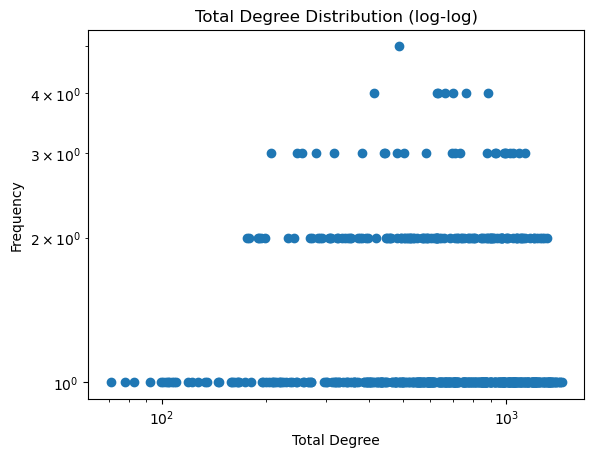

In [46]:
# Frequency of total degrees (in + out)
deg = [d for _, d in Gw.degree()]
deg_freq = Counter(deg)

# Sort degrees
tot_x = sorted(deg_freq.keys())  
tot_y = [deg_freq[k] for k in tot_x]

plt.figure()
plt.loglog(tot_x, tot_y, marker="o", linestyle="None")
plt.xlabel("Total Degree")
plt.ylabel("Frequency")
plt.title("Total Degree Distribution (log-log)")
plt.show()

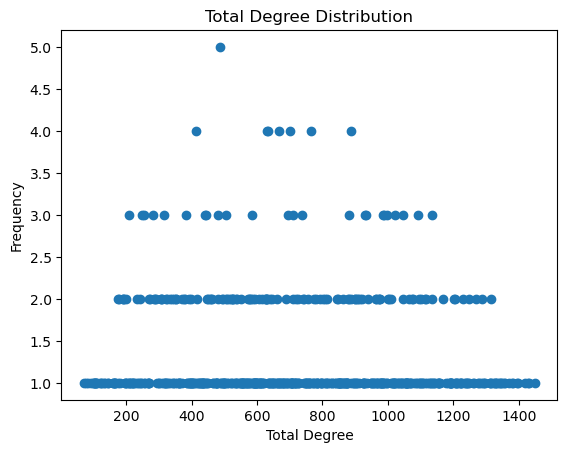

In [47]:
plt.figure()
plt.plot(tot_x, tot_y, marker="o", linestyle="None")
plt.xlabel("Total Degree")
plt.ylabel("Frequency")
plt.title("Total Degree Distribution")
plt.show()

### Diameter and Average Shortest Path

In [48]:
num_components = nx.number_strongly_connected_components(Gw)
largest_scc = max(nx.strongly_connected_components(Gw), key=len)
Gscc = Gw.subgraph(largest_scc).copy()

diam = nx.diameter(Gscc)
avg_len = nx.average_shortest_path_length(Gscc)

print("SCCs of Gw:", num_components)
print("Diameter (directed, on largest SCC):", diam)
print("Average shortest path (directed, on largest SCC):", avg_len)
print("Nodes in SCC:", Gscc.number_of_nodes())

SCCs of Gw: 1
Diameter (directed, on largest SCC): 3
Average shortest path (directed, on largest SCC): 1.5209003156155978
Nodes in SCC: 737
